In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras import layers, models, Sequential
import matplotlib.pyplot as plt
import numpy as np

# Constants
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS = 3
EPOCHS = 50
DATASET_PATH = "/kaggle/input/potato-disease-data/PlantVillage - Copy"  # Change this to your dataset path

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# Load dataset
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 5403 files belonging to 3 classes.


In [3]:
# Get class names
class_names = dataset.class_names
print("Class names:", class_names)


Class names: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


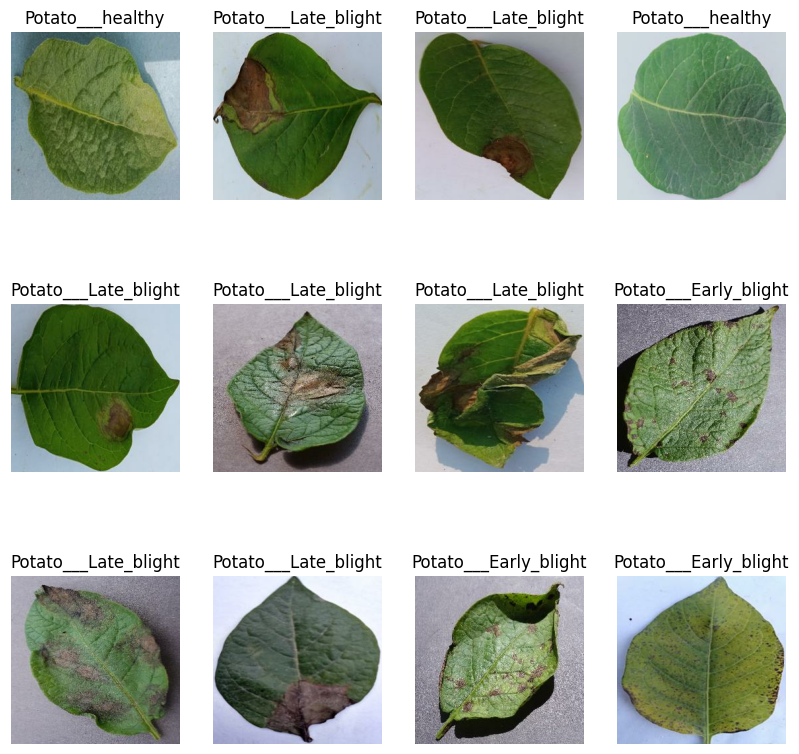

In [4]:
# Visualize 12 sample images
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")
plt.show()

In [5]:
# Split dataset
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + val_split + test_split) == 1
    ds_size = 5403

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=123)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size // BATCH_SIZE)
    val_ds = ds.skip(train_size // BATCH_SIZE).take(val_size // BATCH_SIZE)
    test_ds = ds.skip((train_size + val_size) // BATCH_SIZE)

    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [6]:
# Prefetch and cache datasets
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [7]:
# Data augmentation layer
data_augmentation = Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

In [8]:
# Apply augmentation to training set
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))


In [9]:
# Resize and rescale layer
resize_and_rescale = Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1./255),
])


In [10]:
# Build the CNN model
n_classes = 3
model = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.build(input_shape=(None, IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
model.summary()


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_1 (Sequential)   (None, 256, 256, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 127, 127, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 62, 62, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 60, 60, 128)      

In [11]:
# Compile the model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [12]:
# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/50
135/135 [==============================] - 56s 311ms/step - loss: 0.8944 - accuracy: 0.5460 - val_loss: 1.1794 - val_accuracy: 0.5566
Epoch 2/50
135/135 [==============================] - 37s 273ms/step - loss: 0.6526 - accuracy: 0.7175 - val_loss: 0.5561 - val_accuracy: 0.8574
Epoch 3/50
135/135 [==============================] - 37s 270ms/step - loss: 0.5032 - accuracy: 0.8090 - val_loss: 0.4004 - val_accuracy: 0.8555
Epoch 4/50
135/135 [==============================] - 36s 269ms/step - loss: 0.3663 - accuracy: 0.8730 - val_loss: 0.2513 - val_accuracy: 0.9160
Epoch 5/50
135/135 [==============================] - 36s 269ms/step - loss: 0.2179 - accuracy: 0.9238 - val_loss: 0.2207 - val_accuracy: 0.9316
Epoch 6/50
135/135 [==============================] - 36s 267ms/step - loss: 0.2050 - accuracy: 0.9298 - val_loss: 0.2026 - val_accuracy: 0.9043
Epoch 7/50
135/135 [==============================] - 36s 268ms/step - loss: 0.1700 - accuracy: 0.9370 - val_loss: 0.0861 - val_ac

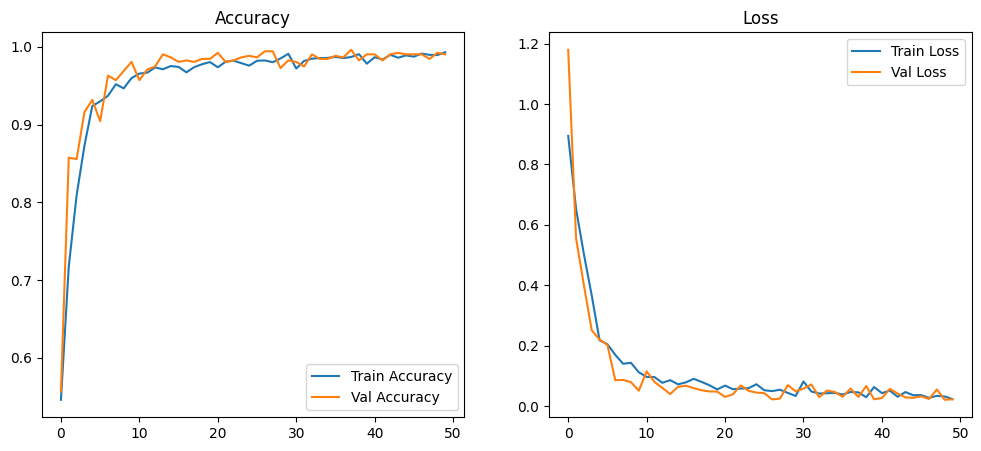

In [13]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label="Train Accuracy")
plt.plot(val_acc, label="Val Accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.title("Loss")
plt.legend()
plt.show()


In [14]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc*100:.2f}%")


18/18 [==============================] - 5s 25ms/step - loss: 0.0182 - accuracy: 0.9948
Test Accuracy: 99.48%


1/1 [==============================] - 0s 240ms/step
Predicted Label: Potato___Late_blight


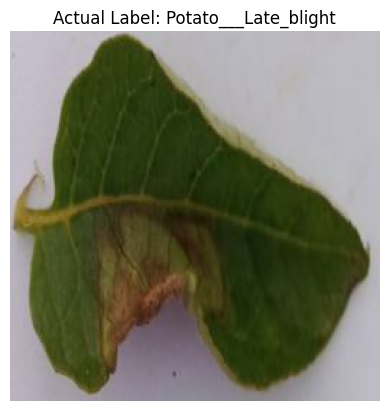

In [15]:
for images_batch, labels_batch in test_ds.take(1):
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    plt.imshow(first_image)
    plt.title(f"Actual Label: {class_names[first_label]}")
    plt.axis("off")
    
    prediction = model.predict(tf.expand_dims(images_batch[0], 0))
    predicted_label = class_names[np.argmax(prediction)]
    print("Predicted Label:", predicted_label)


1/1 [==============================] - 0s 19ms/step


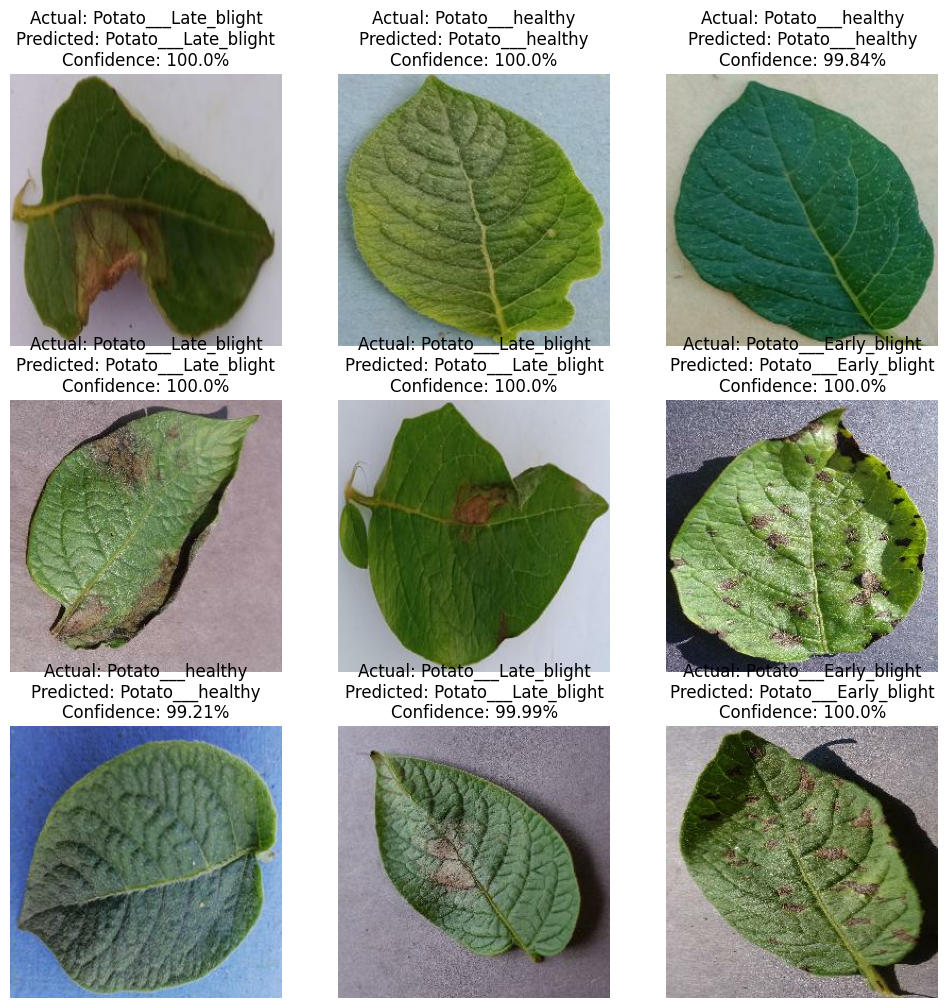

In [16]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)
    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * np.max(predictions[0]), 2)
    return predicted_class, confidence

plt.figure(figsize=(12, 12))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]
        plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence}%")
        plt.axis("off")


In [17]:
model.save("PlantDiseaseClassifier_version_3.h5")  # Save in HDF5 format


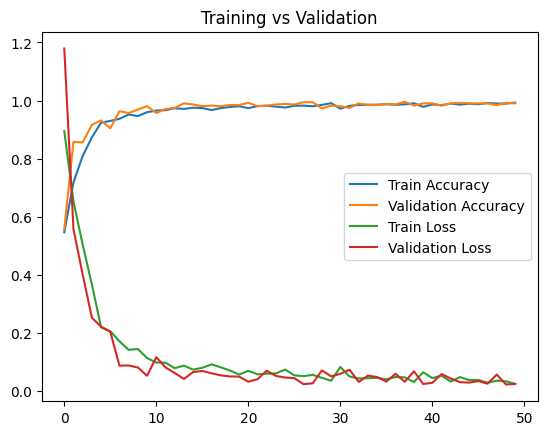

In [18]:
import matplotlib.pyplot as plt

# Example: `history` is the output of model.fit()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation")
plt.show()


In [19]:
import pandas as pd

# Convert history to DataFrame
history_df = pd.DataFrame(history.history)

# Print or display the table
print(history_df)

# Optional: to see only specific columns
print(history_df[['accuracy', 'val_accuracy', 'loss', 'val_loss']])


        loss  accuracy  val_loss  val_accuracy
0   0.894439  0.546002  1.179359      0.556641
1   0.652636  0.717497  0.556067      0.857422
2   0.503250  0.809038  0.400419      0.855469
3   0.366285  0.873001  0.251298      0.916016
4   0.217948  0.923754  0.220664      0.931641
5   0.204958  0.929780  0.202645      0.904297
6   0.169961  0.936964  0.086052      0.962891
7   0.140487  0.951796  0.086719      0.957031
8   0.143483  0.946466  0.079747      0.968750
9   0.112231  0.959676  0.051252      0.980469
10  0.096848  0.965469  0.115128      0.957031
11  0.096359  0.966628  0.080217      0.970703
12  0.077351  0.973349  0.060619      0.974609
13  0.086208  0.971031  0.040272      0.990234
14  0.072339  0.975203  0.063990      0.986328
15  0.078775  0.974044  0.067877      0.980469
16  0.090602  0.967092  0.059717      0.982422
17  0.080430  0.973812  0.052702      0.980469
18  0.069439  0.977520  0.048851      0.984375
19  0.055430  0.980301  0.048339      0.984375
20  0.068200 

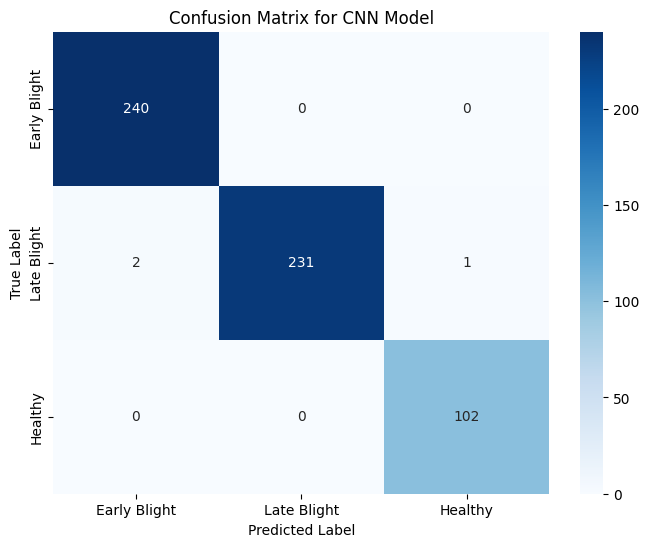


Classification Report:

              precision    recall  f1-score   support

Early Blight       0.99      1.00      1.00       240
 Late Blight       1.00      0.99      0.99       234
     Healthy       0.99      1.00      1.00       102

    accuracy                           0.99       576
   macro avg       0.99      1.00      0.99       576
weighted avg       0.99      0.99      0.99       576



In [20]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in test_ds.unbatch():
    images = tf.expand_dims(images, axis=0)
    predictions = model.predict(images, verbose=0)
    y_pred.append(np.argmax(predictions))
    y_true.append(labels.numpy())

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
class_names = ['Early Blight', 'Late Blight', 'Healthy']

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for CNN Model')
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))
